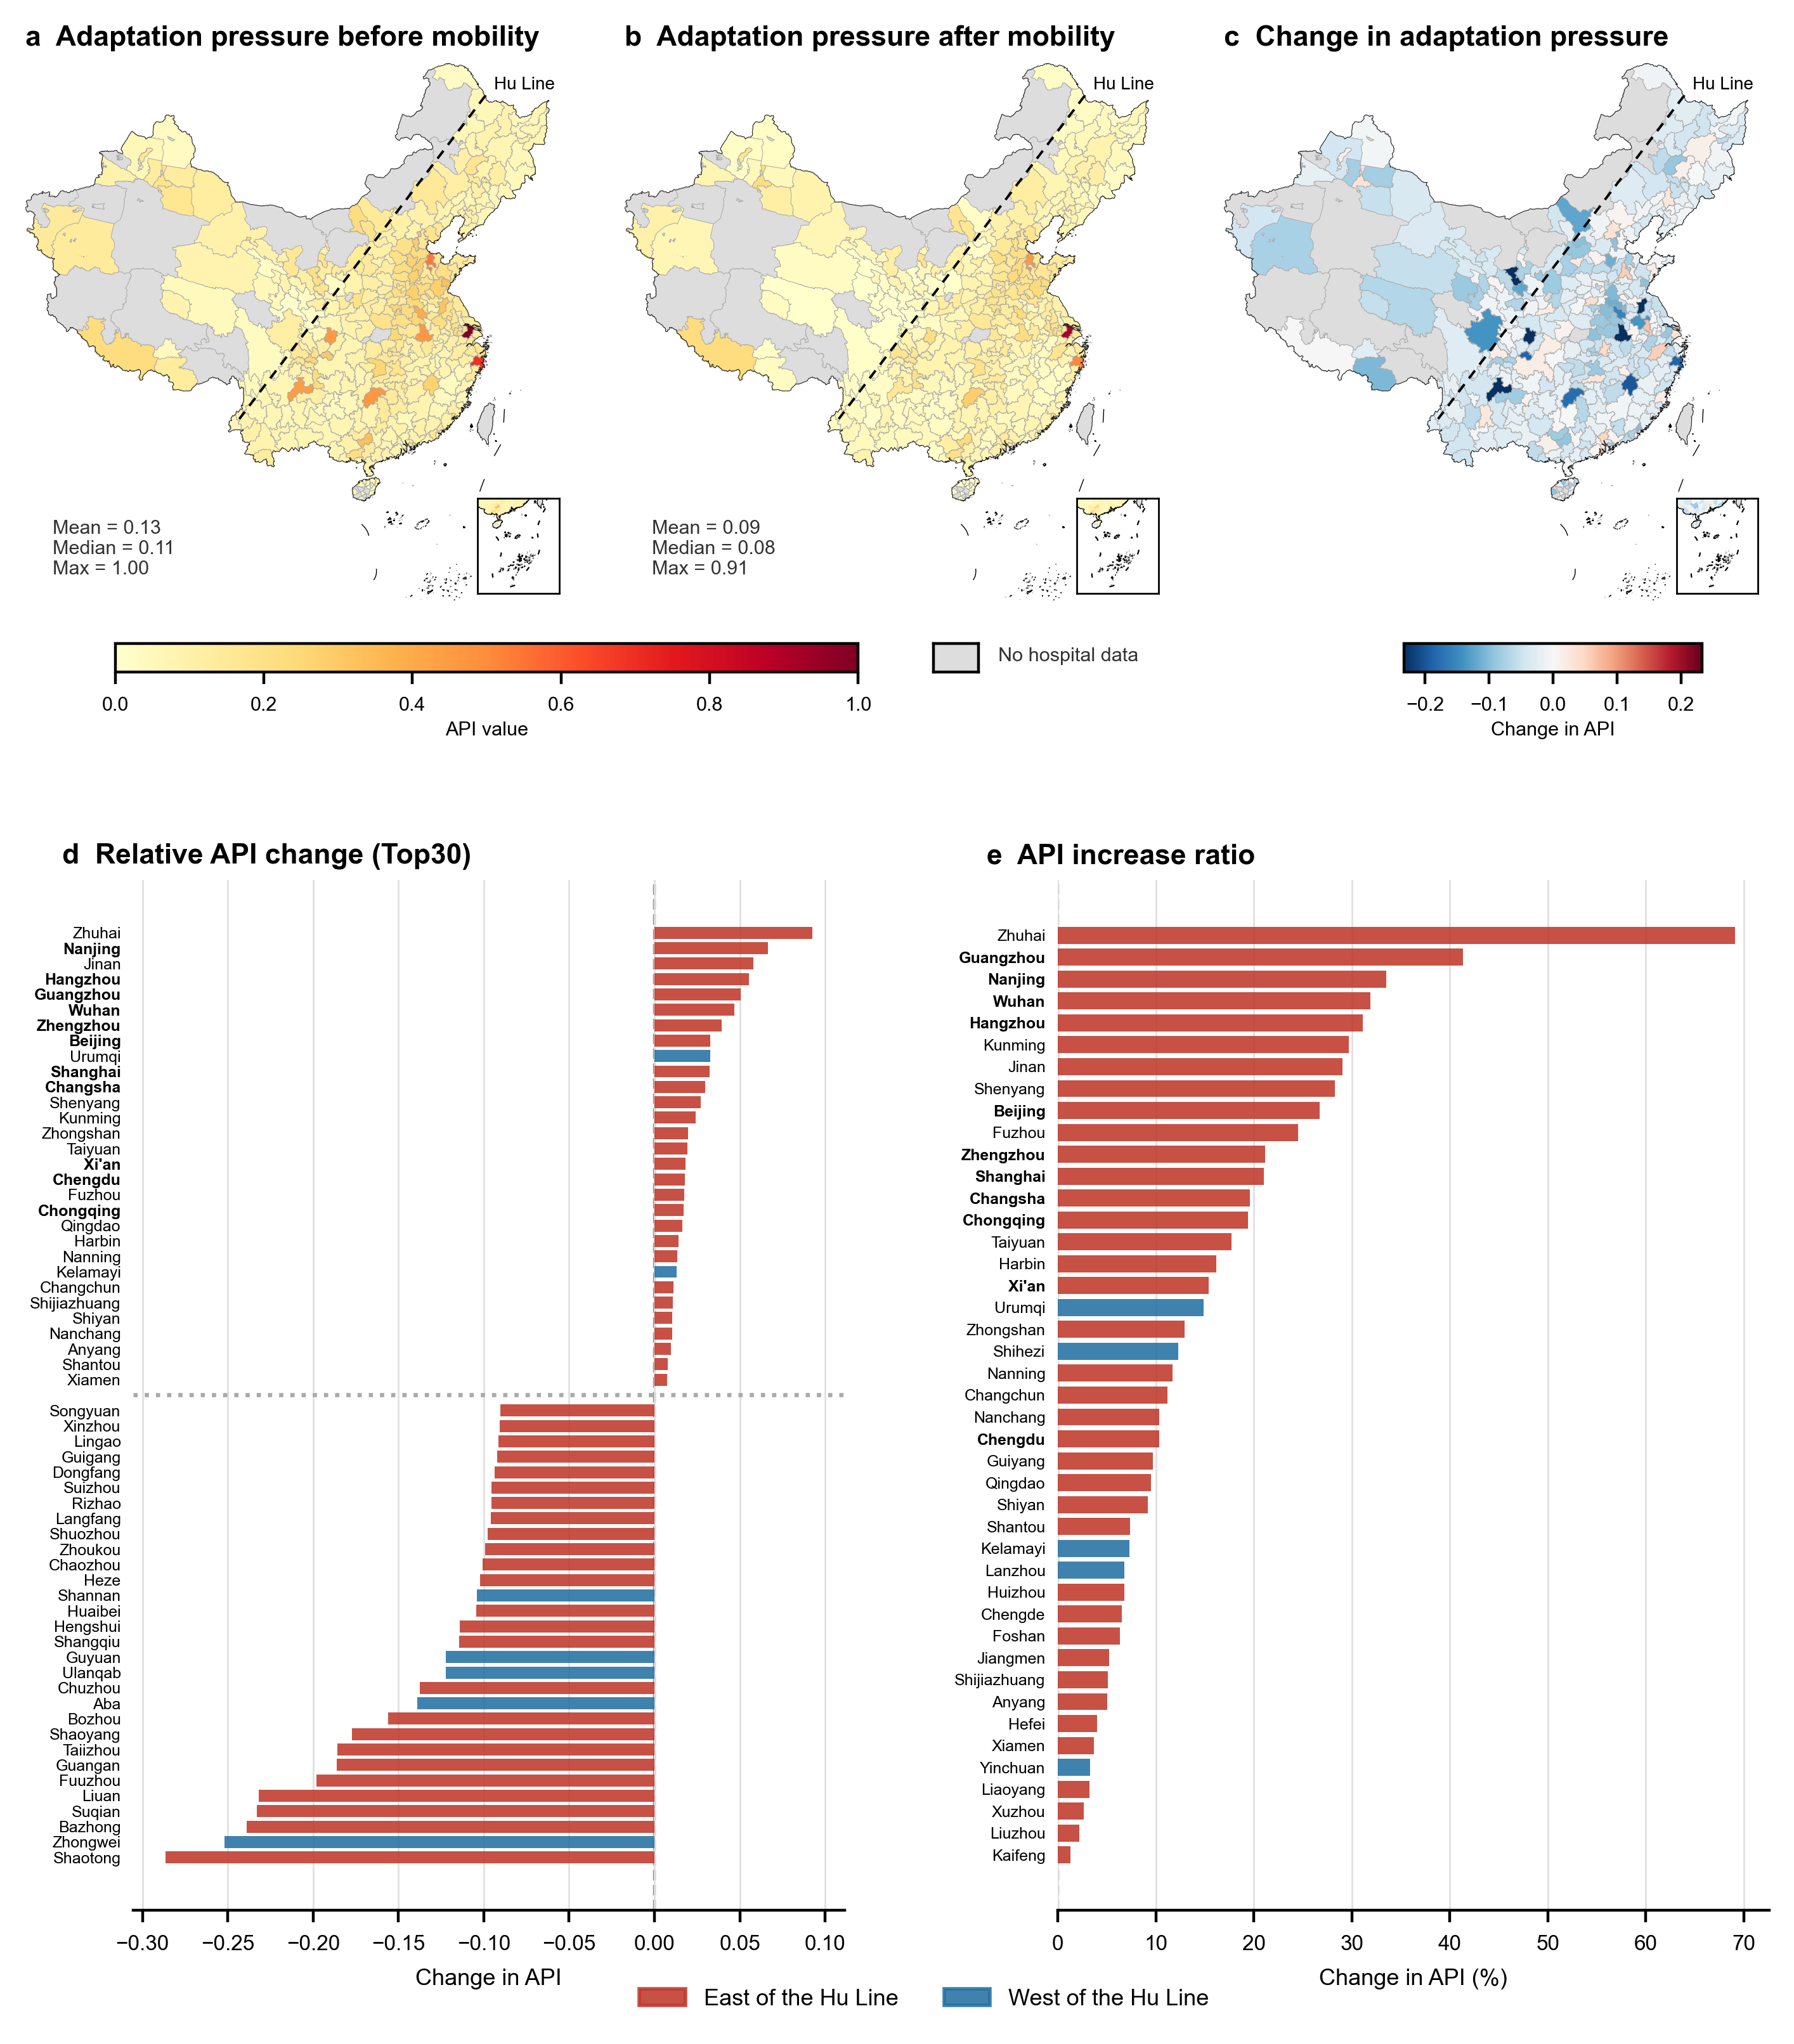

Saved → /Users/shirley/Desktop/plots_V2/Fig4.png


In [17]:
# =============================================================================
# Fig4: Adaptation Pressure Index (API) — 3 choropleth maps + 2 bar charts
# 视觉增强版：NaN 区域灰色覆盖 + 底部水平图例完美并构标注
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
INPUT_FILE = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/air_pollution/data source/hospital/13-National hospital directory.xlsx")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig4.png")

SCENARIO   = "earlypeak_NZ_CL"
YEARS      = [2020, 2030, 2040, 2050, 2060]

CITY_NAME_MAP = {
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
    "Yiichun":   "Yichun",
    "Xiuqian":   "Suqian",
    "Yuulin":    "Yulin",
    "Wulanchabu":"Ulanqab",
}

BOLD_CITIES = {
   "Beijing", "Shanghai", "Guangzhou", "Tianjin", "Hangzhou", "Nanjing", 
   "Wuhan", "Zhengzhou", "Chongqing", "Xi'an", "Chengdu", "Shenzhen", "Changsha"
}

C_EAST   = "#C0392B"
C_WEST   = "#2471A3"
C_NODATA = "#DDDDDD" 
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")

region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities,  fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    net      = (inflow - outflow).rename("net")
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out = df_local.loc[common].copy()
    out["net"]    = net.loc[common].values
    out["demand"] = out["net"] + out["local_patient"]
    return out

# ── 4. Resource Loader ────────────────────────────────────────────────────────
def load_resource():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city", "beds", "clinics"])
    df = df[(df["beds"] > 0) & (df["clinics"] > 0)]
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df["resource"] = np.log(df["beds"] * df["clinics"])
    return df.groupby("city")["resource"].sum()

# ── 5. Compute API Data ───────────────────────────────────────────────────────
resource = load_resource()
frames   = [compute_year(y) for y in YEARS]
avg      = pd.concat(frames).groupby(level=0).mean()

common   = avg.index.intersection(resource.index)
avg      = avg.loc[common]
res      = resource.loc[common]

raw_before = avg["mo_total"] / res
raw_after  = avg["demand"]   / res


global_max = max(raw_before.max(), raw_after.max())

avg["API_before"] = raw_before / global_max
avg["API_after"]  = raw_after  / global_max
avg["delta_API"]  = avg["API_after"] - avg["API_before"]
avg["API_ratio"]  = np.where(avg["API_after"] > 0, avg["delta_API"] / avg["API_after"], np.nan)
avg["region"]     = avg.index.map(region_map)

# Sorting for bar charts
df_diff  = avg.dropna(subset=["delta_API"]).sort_values("delta_API", ascending=False).copy()
df_ratio = avg[avg["delta_API"] > 0].dropna(subset=["API_ratio"]).sort_values("API_ratio", ascending=False).copy()

# ── 6. Merge with shapefile ───────────────────────────────────────────────────
avg_reset = avg[["API_before", "API_after", "delta_API", "region"]].reset_index().rename(columns={"index": "city"})
shp = city_shp.merge(avg_reset, left_on="English", right_on="city", how="left")

# ── 7. Nanhai inset helper ────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, target_shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.83, 0.01, 0.15, 0.18])
    axins.set_facecolor("white")
    

    target_shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
                    linewidth=0, missing_kwds={"color": C_NODATA, "edgecolor": "none"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")

# ── 8. Map drawing helpers ────────────────────────────────────────────────────
def _map_base(ax, col, norm, cmap, title, panel):
    """Draw base map layers shared by all three maps."""
    # 修改点 2：主图中缺失值（NaN，即没有医院资源信息的区域）统一由 missing_kwds 渲染为学术灰色
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": C_NODATA, "edgecolor": "#AAAAAA"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
            "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.10, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(-0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    _add_nanhai_inset(ax, shp, col, norm, cmap)

def draw_map(ax, col, title, panel):
    """Standard map (YlOrRd) for API levels."""
    norm = Normalize(vmin=0, vmax=1)
    cmap = "YlOrRd"
    _map_base(ax, col, norm, cmap, title, panel)
    
    v = avg[col].dropna()
    mean_v, median_v, max_v = v.mean(), v.median(), v.max()
    ax.text(0.05, 0.04,
            f"Mean = {mean_v:.2f}\nMedian = {median_v:.2f}\nMax = {max_v:.2f}",
            transform=ax.transAxes, fontsize=5.5, color="#333333", va="bottom", ha="left")

def draw_diff_map(ax, title, panel):
    """Diverging map for ΔAPI."""
    dmax  = shp["delta_API"].abs().quantile(0.99)
    norm  = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    cmap  = "RdBu_r"  
    _map_base(ax, "delta_API", norm, cmap, title, panel)
    return norm, cmap

# ── 9. Layout: 3 maps (top row) + 2 bar charts (bottom) ─────────────────────
fig = plt.figure(figsize=(18 / 2.54, 24 / 2.54), dpi=400, facecolor="white")

gs_maps = GridSpec(
    1, 3, figure=fig, hspace=0.0, wspace=0.10, left=0, right=0.97, top=0.97, bottom=0.45,
)
ax_mapA = fig.add_subplot(gs_maps[0, 0])
ax_mapB = fig.add_subplot(gs_maps[0, 1])
ax_mapC = fig.add_subplot(gs_maps[0, 2])

gs_bars = GridSpec(
    1, 2, figure=fig, width_ratios=[1, 1], hspace=0.0, wspace=0.30, left=0.06, right=0.97, top=0.48, bottom=0.05,
)
ax_barC = fig.add_subplot(gs_bars[0, 0])
ax_barD = fig.add_subplot(gs_bars[0, 1])

# ── 10. Draw maps ─────────────────────────────────────────────────────────────
draw_map(ax_mapA, "API_before", "Adaptation pressure before mobility", "a")
draw_map(ax_mapB, "API_after",  "Adaptation pressure after mobility",  "b")
norm_diff, cmap_diff = draw_diff_map(ax_mapC, "Change in adaptation pressure", "c")


fig.canvas.draw()
pos_a = ax_mapA.get_position()
pos_b = ax_mapB.get_position()
pos_c = ax_mapC.get_position()

cbar_h      = 0.012
cbar_bottom = pos_a.y0 - 0.03


cbar_ax_ab = fig.add_axes([pos_a.x0 + 0.05, cbar_bottom, (pos_b.x1 * 0.8 - (pos_a.x0 + 0.05)) * 0.9, cbar_h])
sm_ab = mcm.ScalarMappable(cmap="YlOrRd", norm=Normalize(vmin=0, vmax=1))
sm_ab.set_array([])
cbar_ab = fig.colorbar(sm_ab, cax=cbar_ax_ab, orientation="horizontal")
cbar_ab.ax.tick_params(labelsize=5.5)
cbar_ab.set_label("API value", fontsize=5.5, labelpad=2)


rect_ax_ab = fig.add_axes([(pos_b.x1 * 0.8 - (pos_a.x0 + 0.05))*1.1 , cbar_bottom , 0.025, cbar_h])
rect_ax_ab.patch.set_facecolor(C_NODATA)
rect_ax_ab.patch.set_edgecolor("#AAAAAA")
rect_ax_ab.patch.set_linewidth(0.3)
rect_ax_ab.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
fig.text(pos_b.x1 * 0.85, cbar_bottom + 0.003, "No hospital data", fontsize=5.5, color="#333333", va="bottom")



cbar_ax_c = fig.add_axes([pos_c.x0 * 1.15, cbar_bottom, (pos_c.x1 * 0.95 - pos_c.x0 * 1.05) * 0.75, cbar_h])
sm_c = mcm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, cax=cbar_ax_c, orientation="horizontal")
cbar_c.ax.tick_params(labelsize=5.5)
cbar_c.set_label("Change in API", fontsize=5.5, labelpad=2)




# ── 12. Bar style helper ──────────────────────────────────────────────────────
def style_bar(ax, title, xlabel):
    ax.text(-0.10, 1.01, title, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=6.5)
    ax.axvline(0, color="#888", lw=0.8, ls="--", zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=6.5)
    ax.tick_params(axis="x", labelsize=6)
    ax.grid(axis="x", color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_facecolor("white")

# ── 13. Bar C: Top 30 / Bottom 30 Relative API change ────────────────────────
style_bar(ax_barC, "d  Relative API change (Top30)", "Change in API")

top30 = df_diff.head(30)
bot30 = df_diff.tail(30)
gap_row = pd.DataFrame({col: [np.nan] for col in df_diff.columns}, index=[""])
df_c  = pd.concat([top30, gap_row, bot30])
n_c   = len(df_c)
y_c   = np.arange(n_c)
colors_c = [
    C_EAST if r == "East" else (C_WEST if r == "West" else "#FFFFFF") for r in df_c["region"]
]
ax_barC.barh(y_c, df_c["delta_API"].values, color=colors_c, height=0.78, alpha=0.88, zorder=2)
ax_barC.set_yticks(y_c)
ax_barC.set_yticklabels(df_c.index, fontsize=4.5)

for label in ax_barC.get_yticklabels():
    if label.get_text() in BOLD_CITIES:
        label.set_weight("bold")
        label.set_color("black")

ax_barC.axhline(30, color="#AAAAAA", lw=1.2, ls=":", zorder=3)
ax_barC.invert_yaxis()

# ── 14. Bar D: All cities with increased API ─────────────────────────────────
style_bar(ax_barD, "e  API increase ratio", "Change in API (%)")

n_d      = len(df_ratio)
y_d      = np.arange(n_d)
colors_d = [C_EAST if r == "East" else C_WEST for r in df_ratio["region"]]
ratio_pct = df_ratio["API_ratio"].values * 100

ax_barD.barh(y_d, ratio_pct, color=colors_d, height=0.78, alpha=0.88, zorder=2)
ax_barD.set_yticks(y_d)
ax_barD.set_yticklabels(df_ratio.index, fontsize=4.5)

for label in ax_barD.get_yticklabels():
    if label.get_text() in BOLD_CITIES:
        label.set_weight("bold")
        label.set_color("black")

ax_barD.invert_yaxis()

# ── 15. Shared legend ─────────────────────────────────────────────────────────
patch_e = mpatches.Patch(color=C_EAST, label="East of the Hu Line", alpha=0.88)
patch_w = mpatches.Patch(color=C_WEST, label="West of the Hu Line", alpha=0.88)
fig.legend(handles=[patch_e, patch_w], loc="lower center", ncol=2,
           fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, 0.0))

# ── 16. Save ──────────────────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUTFILE}")